# Importing libraries

In [3]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import matplotlib.dates as mdates
from datetime import datetime,timedelta

from oceanicospy.observations import AWAC,AQUAlogger,WeatherStation,ResistiveSensor
#from oceanicospy.analysis import spectral,temporal

# Out reef buoy vs SWAN output

## Reading and storing SWAN data

In [52]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")

# -------------------- Read and prepare the table -------------------- #
path_case = '/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_ERA5/run'
points = pd.read_csv(
    f'{path_case}/domain_03/SalidasSWAN.out',
    skiprows=7, sep=r'\s+', index_col=0,
    names=['Time', 'Xp', 'Yp', 'Depth', 'X-Windv','Y-Windv', 'Hsig', 'TPsmoo', 'Tm01', 'Tm02', 'Dir'],
    dtype={'Time': str, 'Xp': float, 'Yp': float, 'Depth': float, 'X-Windv': float, 'Y-Windv': float,
           'Hsig': float, 'TPsmoo': float, 'Tm01': float, 'Tm02': float, 'Dir': float}
)

# Parse index to true datetime and ensure tz-naive
points.index = pd.to_datetime(points.index, format='%Y%m%d.%H%M%S', errors='coerce').tz_localize(None)
points = points.sort_index()

# -------------------- Crop by datetime BEFORE building dicts (cleanest) -------------------- #
points_crop = points.loc[start_datetime:end_datetime]

# -------------------- Build the dictionaries (Hs and Tp) -------------------- #
number_of_points = np.arange(0, 2, 1)  # adapt as needed

dict_data_hs = {}
dict_data_tp = {}
for point in number_of_points:
    # Every "point" picks every N-th row, starting at its offset
    dict_data_hs[point + 1] = points_crop['Hsig'][point::len(number_of_points)]
    dict_data_tp[point + 1] = points_crop['TPsmoo'][point::len(number_of_points)]

# Common time vector (example: from point 1)
time = dict_data_hs[1].index

# Final container
time_series_sims = {'hs': dict_data_hs, 'tp': dict_data_tp}

## Reading and storing field data

In [53]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Out_Reef/buoy_outreef_may2023.csv'


# Read CSV with the first row as column headers
df_outreef_buoy = pd.read_csv(file_path, header=0)
df_outreef_buoy["date"] = pd.to_datetime(df_outreef_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_outreef_buoy = df_outreef_buoy.loc[
    (df_outreef_buoy["date"] >= start_datetime) &
    (df_outreef_buoy["date"] <= end_datetime)
]

df_outreef_buoy

,date,Hs[m],Tp[s],Dir[°]
260,2023-05-12 08:00:00,1.76,5.84,56.566
261,2023-05-12 09:00:00,1.84,5.82,59.371
262,2023-05-12 10:00:00,2.83,9.20,65.154
263,2023-05-12 11:00:00,1.94,5.92,64.186
264,2023-05-12 12:00:00,1.86,5.46,66.251
...,...,...,...,...
670,2023-05-30 04:00:00,0.81,5.30,80.441
671,2023-05-30 05:00:00,0.82,5.30,82.552
672,2023-05-30 06:00:00,0.78,5.36,82.811
673,2023-05-30 07:00:00,0.81,5.60,81.111


## Plot

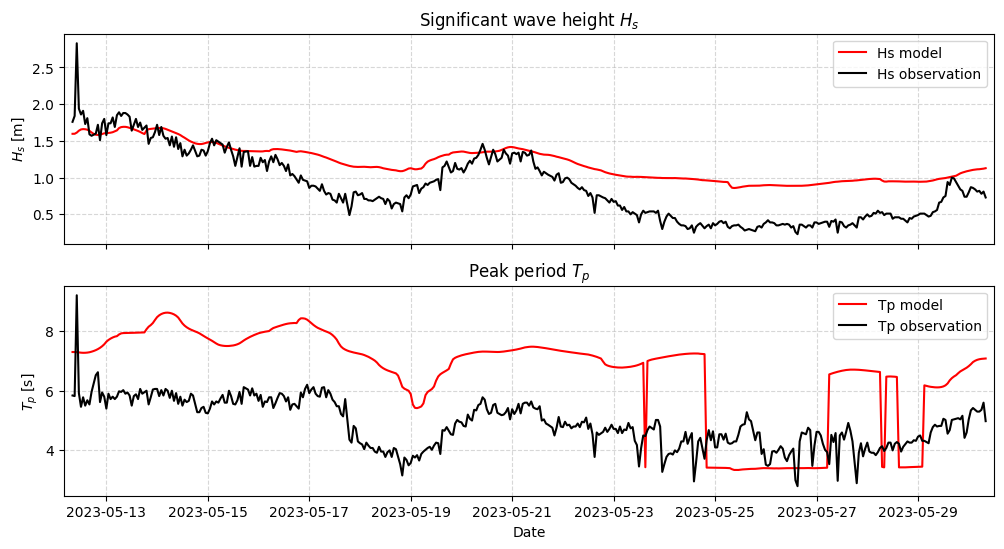

In [54]:
fig, [ax1,ax2] = plt.subplots(2,1,figsize=(12, 6),sharex=True)

ax1.plot(time,dict_data_hs[1],color='r',label='Hs model')
ax1.plot(df_outreef_buoy['date'],df_outreef_buoy['Hs[m]'],label='Hs observation',color='k')
ax1.set(title='Significant wave height $H_{s}$',ylabel=r'$H_{s}$ [m]',xlim=(datetime(2023,5,12,4,0,0),datetime(2023,5,30,12,0,0)-timedelta(minutes=1)))
ax1.legend()
ax1.grid(alpha=0.5,ls='--')

ax2.plot(time,dict_data_tp[1],color='r',label='Tp model')
ax2.plot(df_outreef_buoy['date'],df_outreef_buoy['Tp[s]'],label='Tp observation',color='k')
ax2.set(title='Peak period $T_{p}$',xlabel='Date',ylabel=r'$T_{p}$ [s]',xlim=(datetime(2023,5,12,4,0,0),datetime(2023,5,30,12,0,0)-timedelta(minutes=1)))
ax2.legend()
ax2.grid(alpha=0.5,ls='--')

plt.show()

# Lagoon buoy vs SWAN output

## Reading and storing SWAN data

In [47]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")

# -------------------- Read and prepare the table -------------------- #
path_case = '/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_ERA5/run'
points = pd.read_csv(
    f'{path_case}/domain_03/SalidasSWAN.out',
    skiprows=7, sep=r'\s+', index_col=0,
    names=['Time', 'Xp', 'Yp', 'Depth', 'X-Windv','Y-Windv', 'Hsig', 'TPsmoo', 'Tm01', 'Tm02', 'Dir'],
    dtype={'Time': str, 'Xp': float, 'Yp': float, 'Depth': float, 'X-Windv': float, 'Y-Windv': float,
           'Hsig': float, 'TPsmoo': float, 'Tm01': float, 'Tm02': float, 'Dir': float}
)

# Parse index to true datetime and ensure tz-naive
points.index = pd.to_datetime(points.index, format='%Y%m%d.%H%M%S', errors='coerce').tz_localize(None)
points = points.sort_index()

# -------------------- Crop by datetime BEFORE building dicts (cleanest) -------------------- #
points_crop = points.loc[start_datetime:end_datetime]

# -------------------- Build the dictionaries (Hs and Tp) -------------------- #
number_of_points = np.arange(0, 2, 1)  # adapt as needed

dict_data_hs = {}
dict_data_tp = {}
for point in number_of_points:
    # Every "point" picks every N-th row, starting at its offset
    dict_data_hs[point + 1] = points_crop['Hsig'][point::len(number_of_points)]
    dict_data_tp[point + 1] = points_crop['TPsmoo'][point::len(number_of_points)]

# Common time vector (example: from point 1)
time = dict_data_hs[1].index

# Final container
time_series_sims = {'hs': dict_data_hs, 'tp': dict_data_tp}

## Reading and storing field data

In [48]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Lagoon/buoy_lagoon_may2023.csv'


# Read CSV with the first row as column headers
df_outreef_buoy = pd.read_csv(file_path, header=0)
df_outreef_buoy["date"] = pd.to_datetime(df_outreef_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_outreef_buoy = df_outreef_buoy.loc[
    (df_outreef_buoy["date"] >= start_datetime) &
    (df_outreef_buoy["date"] <= end_datetime)
]

df_outreef_buoy

,date,Hs[m],Tp[s],Dir[°]
136,2023-05-12 09:00:00,0.245,5.69,179.2245
137,2023-05-12 11:00:00,0.235,6.30,190.1150
138,2023-05-12 13:00:00,0.195,5.75,258.3210
139,2023-05-12 15:00:00,0.210,4.75,205.1780
140,2023-05-12 17:00:00,0.230,4.71,267.3820
...,...,...,...,...
346,2023-05-29 23:00:00,0.145,3.65,340.2195
347,2023-05-30 01:00:00,0.145,3.93,333.2355
348,2023-05-30 03:00:00,0.125,4.17,328.6600
349,2023-05-30 05:00:00,0.120,4.57,309.2155


# Plot

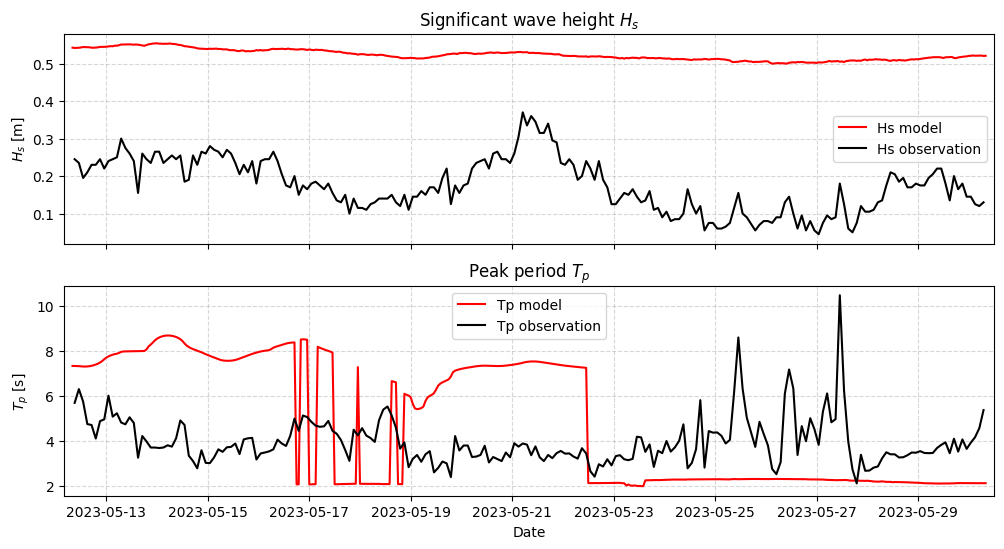

In [51]:
fig, [ax1,ax2] = plt.subplots(2,1,figsize=(12, 6),sharex=True)

ax1.plot(time,dict_data_hs[2],color='r',label='Hs model')
ax1.plot(df_outreef_buoy['date'],df_outreef_buoy['Hs[m]'],label='Hs observation',color='k')
ax1.set(title='Significant wave height $H_{s}$',ylabel=r'$H_{s}$ [m]',xlim=(datetime(2023,5,12,4,0,0),datetime(2023,5,30,12,0,0)-timedelta(minutes=1)))
ax1.legend()
ax1.grid(alpha=0.5,ls='--')

ax2.plot(time,dict_data_tp[2],color='r',label='Tp model')
ax2.plot(df_outreef_buoy['date'],df_outreef_buoy['Tp[s]'],label='Tp observation',color='k')
ax2.set(title='Peak period $T_{p}$',xlabel='Date',ylabel=r'$T_{p}$ [s]',xlim=(datetime(2023,5,12,4,0,0),datetime(2023,5,30,12,0,0)-timedelta(minutes=1)))
ax2.legend()
ax2.grid(alpha=0.5,ls='--')

plt.show()




processed_data_path = '/scratchsan/medellin/ffayalac/tracking_IG_energy/data/processed/fourier'

sampling_AQ1=dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=1,burst_length_s=2048,temperature=False,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,9,18,0,0)-timedelta(minutes=1))
sampling_AQ2=dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=1,burst_length_s=2048,temperature=False,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,9,18,0,0)-timedelta(minutes=1))
sampling_RBR1=dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=2,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,9,18,0,0)-timedelta(minutes=1))
sampling_RBR2=dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=2,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,9,18,0,0)-timedelta(minutes=1))

sampling_data = [sampling_AQ1, sampling_AQ2,sampling_RBR1,sampling_RBR2]
metadata_list=['AQ1_May_2025_SB','AQ2_May_2025_SB','RBR1_May_2025_SB','RBR2_May_2025_SB']

dict_spectra = dict()
dict_integral_params = dict()

spectrum_type = 'fft'

for id in metadata_list:
    spectra_data_path = f'{processed_data_path}/{id}_spectra_{spectrum_type}.npz'
    integral_params_data_path =  f'{processed_data_path}/{id}_params_{spectrum_type}.npz'
    dict_spectra[id] = np.load(spectra_data_path)
    dict_integral_params[id] = np.load(integral_params_data_path)

path_case='/scratchsan/medellin/ffayalac/runs/swan_SA/May2025/run'

dict_sims = {}

points = pd.read_csv(f'{path_case}/domain_04/SalidasSWAN.out', skiprows=7, sep='\s+', index_col=0,
                        names=['Time', 'Xp', 'Yp', 'Depth', 'X-Windv','Y-Windv', 'Hsig', 'TPsmoo', 'Tm01', 'Tm02', 'Dir'],
                        dtype={'Time': str, 'Xp': float, 'Yp': float, 'Depth': float, 'X-Windv': float, 'Y-Windv': float, 'Hsig': float, 'TPsmoo': float, 'Tm01': float, 'Tm02': float, 'Dir': float})
points['Time'] = pd.to_datetime(points.index, format='%Y%m%d.%H%M%S')
points.set_index('Time', inplace=True)

number_of_points = np.arange(0, 15, 1)

dict_data_hs = {}
dict_data_tp = {}
for point in number_of_points:
    hs_point_serie_300 = points['Hsig'][point::len(number_of_points)]
    dict_data_hs[point + 1] = hs_point_serie_300
    tp_point_serie_300 = points['TPsmoo'][point::len(number_of_points)]
    dict_data_tp[point + 1] = tp_point_serie_300
    if point==1:
        time = points.index[point::len(number_of_points)]

time_series_sims = {'hs': dict_data_hs, 'tp': dict_data_tp}

fig, [ax1,ax2] = plt.subplots(2,1,figsize=(12, 6),sharex=True)

print(dict_integral_params['RBR2_May_2025_SB'].keys())

ax1.plot(time,dict_data_hs[15],color='r',label='model')
ax1.plot(dict_spectra['RBR2_May_2025_SB']['time'],dict_integral_params['RBR2_May_2025_SB']['Hm0'],label='RBR2 observation',color='k')
ax1.set(title='Serie de altura de ola significante $H_{s}$',ylabel=r'Altura de ola, $H_{s}$ [m]')
ax1.legend()
ax1.grid(alpha=0.5,ls='--')

ax2.plot(time,dict_data_tp[15],color='r',label='model')
ax2.plot(dict_spectra['RBR2_May_2025_SB']['time'],dict_integral_params['RBR2_May_2025_SB']['Tp'],label='RBR2 observation',color='k')
ax2.set(title='Serie de período pico $T_{p}$',xlabel='Fecha',ylabel=r'Período pico, $T_{p}$ [s]',xlim=(datetime(2025,5,9,10,0,0),datetime(2025,5,19,18,0,0)-timedelta(minutes=1)))
ax2.legend()
ax2.grid(alpha=0.5,ls='--')

# ax2.plot(df_MLMST["date"][6:-9], df_MLMST[8][6:-9],label='AW600 obs.',color='k')

# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
# ax1.grid()
# ax2.grid()

# # Create a legend outside the plot
# plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=4)

# # Adjust the spacing between subplots to make room for the legend
# plt.subplots_adjust(bottom=0.2)

plt.savefig(f'hs_tp_model_RBR2.png', dpi=200, bbox_inches='tight', pad_inches=0.1)

# fig, [ax1,ax2] = plt.subplots(2,1,figsize=(10, 6),sharex=True)

# for id_domain in range(1,4):
#     dict_data_hs = time_series_sims[id_domain]['hs']
#     dict_data_tp = time_series_sims[id_domain]['tp']
#     ax1.plot(time,dict_data_hs[2], label=f'Dominio {id_domain}')
#     ax2.plot(time,dict_data_tp[2], label=f'Dominio {id_domain}')

# ax1.plot(params_surflevel.Hm0,label='AW1000 obs. (Fourier)',color='k')
# ax1.plot(params_puv.Hm0,label='AW1000 obs. (PUV)',color='gray')
# ax2.plot(params_surflevel.Tp,label='AW1000 obs. (Fourier)',color='k')
# ax2.plot(params_puv.Tp,label='AW1000 obs. (PUV)',color='gray')

# ax1.set_title('Serie de altura de ola significante $H_{s}$ en ubicación AW1000')
# ax2.set_title('Serie de período pico $T_{p}$ en ubicación AW1000')
# ax2.set_xlabel('Fecha')
# ax1.set_ylabel(r'Altura de ola, $H_{s}$ [m]')
# ax2.set_ylabel(r'Período pico, $T_{p}$ [s]')
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
# ax1.grid()
# ax2.grid()

# # Create a legend outside the plot
# plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=4)

# # Adjust the spacing between subplots to make room for the legend
# plt.subplots_adjust(bottom=0.2)

# plt.savefig(f'hs_tp_series_aw1000.png', dpi=200, bbox_inches='tight', pad_inches=0.1)
# # return dict_data

